In [331]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import seaborn as sns
from datetime import datetime, timedelta
import json
import os
import re
import sys
from typing import List, Tuple, Optional, Dict, Literal
from glob import glob
from IPython.display import display, clear_output
import calendar
import math
import july
from plotly_calheatmap import (
    calendar_calheatmap, calheatmap,
    month_calheatmap, hourly_calheatmap
)
from scipy.stats import pearsonr, linregress
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
from scipy.signal import find_peaks
from scipy.signal import detrend
from scipy.fft import fft, fftfreq
from scipy.stats import shapiro, ks_2samp
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
pd.options.display.max_columns = None

In [3]:
def calendar_plot_binary(
    dates,
    data,
    cmap=None,
    title=None,
    figsize=(12, 8),
    ncols=3,
    value_label=False,
    date_label=True,
    month_label=True,
    weeknum_label=False,
):
    """
    Calendar heatmap for binary activity data.

    Parameters
    ----------
    dates : array-like
        Dates corresponding to each activity value.

    data : array-like
        Binary values:
            0 = no activity
            1 = activity

    cmap : matplotlib colormap, optional
        Colormap containing exactly two colours.
        Default:
            0 -> very light grey
            1 -> blue

    title : str, optional
        Overall figure title.

    figsize : tuple
        Figure size.

    ncols : int
        Number of calendar months per row.

    value_label : bool
        Display the activity value inside each day cell.

    date_label : bool
        Display day numbers.

    month_label : bool
        Display month names.

    weeknum_label : bool
        Display week numbers.

    Returns
    -------
    matplotlib.axes.Axes
    """

    # ---------------------------------------------------------
    # Prepare data
    # ---------------------------------------------------------

    df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "value": np.asarray(data)
    })

    df["value"] = df["value"].astype(int)

    # Make sure data is binary
    if not df["value"].isin([0, 1]).all():
        raise ValueError("calendar_plot_binary expects activity values of only 0 and 1.")

    # If duplicate dates exist, keep the maximum activity.
    # Therefore, if anything happened on a day -> activity = 1.
    df = (
        df.groupby("date", as_index=False)["value"]
        .max()
    )

    activity = dict(
        zip(
            df["date"].dt.normalize(),
            df["value"]
        )
    )

    # ---------------------------------------------------------
    # Default binary colour map
    # ---------------------------------------------------------

    if cmap is None:
        cmap = ListedColormap([
            "#eeeeee",   # 0 = no activity
            "#2166ac",   # 1 = activity
        ])

    # Require two colours
    if cmap.N < 2:
        raise ValueError("cmap must contain at least two colours.")

    # ---------------------------------------------------------
    # Determine months to display
    # ---------------------------------------------------------

    min_date = df["date"].min()
    max_date = df["date"].max()

    months = pd.period_range(
        min_date.to_period("M"),
        max_date.to_period("M"),
        freq="M"
    )

    nmonths = len(months)
    nrows = math.ceil(nmonths / ncols)

    # ---------------------------------------------------------
    # Figure
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    # ---------------------------------------------------------
    # Calendar settings
    # ---------------------------------------------------------

    # Monday = 0 ... Sunday = 6
    calendar.setfirstweekday(calendar.MONDAY)

    weekday_names = [
        "Mon", "Tue", "Wed", "Thu",
        "Fri", "Sat", "Sun"
    ]

    # ---------------------------------------------------------
    # Draw each month
    # ---------------------------------------------------------

    for ax_idx, period in enumerate(months):

        ax = axes[ax_idx]

        year = period.year
        month = period.month

        cal = calendar.monthcalendar(year, month)

        nweeks = len(cal)

        # Calendar background
        ax.set_xlim(0, 7)
        ax.set_ylim(nweeks, 0)

        # -----------------------------------------------------
        # Month title
        # -----------------------------------------------------

        if month_label:
            month_name = period.strftime("%B %Y")

            ax.set_title(
                month_name,
                fontsize=11,
                fontweight="bold",
                pad=12
            )

        # -----------------------------------------------------
        # Weekday labels
        # -----------------------------------------------------

        ax.set_xticks(
            np.arange(7) + 0.5
        )

        ax.set_xticklabels(
            weekday_names,
            fontsize=8
        )

        ax.tick_params(
            axis="x",
            bottom=False,
            top=False,
            length=0
        )

        # Remove y axis
        ax.set_yticks([])

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # -----------------------------------------------------
        # Draw days
        # -----------------------------------------------------

        for week_idx, week in enumerate(cal):

            for weekday_idx, day in enumerate(week):

                # Empty cell before/after month
                if day == 0:
                    continue

                date = pd.Timestamp(
                    year=year,
                    month=month,
                    day=day
                )

                value = activity.get(
                    date.normalize(),
                    0
                )

                # -------------------------------------------------
                # FIXED COLOUR MAPPING
                #
                # This is the important part.
                #
                # 0 ALWAYS gets cmap[0]
                # 1 ALWAYS gets cmap[1]
                #
                # There is no per-month normalization.
                # -------------------------------------------------

                cell_color = cmap(value)

                rect = Rectangle(
                    (
                        weekday_idx,
                        week_idx
                    ),
                    1,
                    1,
                    facecolor=cell_color,
                    edgecolor="white",
                    linewidth=1.5
                )

                ax.add_patch(rect)

                # -------------------------------------------------
                # Day number
                # -------------------------------------------------

                if date_label:

                    # Choose text colour based on activity
                    text_color = (
                        "white"
                        if value == 1
                        else "#555555"
                    )

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.5,
                        str(day),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=text_color
                    )

                # -------------------------------------------------
                # Activity value
                # -------------------------------------------------

                if value_label:

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.78,
                        str(value),
                        ha="center",
                        va="center",
                        fontsize=6,
                        color="white" if value == 1 else "#777777"
                    )

        # -----------------------------------------------------
        # Optional week numbers
        # -----------------------------------------------------

        if weeknum_label:

            for week_idx, week in enumerate(cal):

                valid_days = [
                    d for d in week if d != 0
                ]

                if valid_days:

                    first_day = pd.Timestamp(
                        year=year,
                        month=month,
                        day=valid_days[0]
                    )

                    week_number = first_day.isocalendar().week

                    ax.text(
                        -0.18,
                        week_idx + 0.5,
                        str(week_number),
                        ha="right",
                        va="center",
                        fontsize=7,
                        color="#777777"
                    )

        # -----------------------------------------------------
        # Grid boundaries
        # -----------------------------------------------------

        ax.set_xlim(0, 7)
        ax.set_ylim(nweeks, 0)

    # ---------------------------------------------------------
    # Hide unused axes
    # ---------------------------------------------------------

    for i in range(nmonths, len(axes)):
        axes[i].set_visible(False)

    # ---------------------------------------------------------
    # Figure title
    # ---------------------------------------------------------

    if title is not None:

        fig.suptitle(
            title,
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

    plt.tight_layout()

    return axes

In [4]:
def calendar_plot_categorical(
    dates,
    data,
    cmap=None,
    category_colors=None,
    title=None,
    figsize=(12, 8),
    ncols=3,
    value_label=False,
    date_label=True,
    month_label=True,
    weeknum_label=False,
    legend=True,
    legend_title=None,
    missing_color="#F5F5F5",
    missing_label="No data",
):
    """
    Calendar heatmap for categorical data.

    Parameters
    ----------
    dates : array-like
        Dates corresponding to each data value.

    data : array-like
        Categorical values. Can contain any number of categories,
        provided there are at least 2.

        Examples:
            [0, 1]
            ["Good", "Neutral", "Alert"]
            ["Low", "Medium", "High", "Critical"]

    cmap : matplotlib colormap, list of colours, optional
        Colour map used to assign colours to categories.

        Examples:
            "RdYlGn"
            "viridis"
            ["#D32F2F", "#E0E0E0", "#388E3C"]

        If None, a default categorical palette is generated.

    category_colors : dict, optional
        Explicit mapping between categories and colours.

        Example:
            {
                "Alert": "#D32F2F",
                "Neutral": "#E0E0E0",
                "Good": "#388E3C"
            }

        When supplied, this takes precedence over cmap.

    title : str, optional
        Overall figure title.

    figsize : tuple
        Figure size.

    ncols : int
        Number of calendar months per row.

    value_label : bool
        Display category values inside each day cell.

    date_label : bool
        Display day numbers.

    month_label : bool
        Display month names.

    weeknum_label : bool
        Display ISO week numbers.

    legend : bool
        Whether to display a category legend.

    legend_title : str, optional
        Legend title.

    missing_color : str
        Colour for dates that are missing from the input data.

    missing_label : str
        Label used for missing dates in the legend.

    Returns
    -------
    axes : numpy.ndarray
        Array of matplotlib Axes objects.
    """

    # =========================================================
    # Prepare data
    # =========================================================

    df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "value": np.asarray(data)
    })

    # Remove rows with missing dates
    df = df.dropna(subset=["date"])

    if df.empty:
        raise ValueError("No valid dates were provided.")

    # Normalize dates so timestamps such as
    # 2026-01-01 12:00 and 2026-01-01 15:00
    # are treated as the same day.
    df["date"] = df["date"].dt.normalize()

    # =========================================================
    # Validate categories
    # =========================================================

    categories = pd.unique(
        df["value"].dropna()
    ).tolist()

    if len(categories) < 2:
        raise ValueError(
            "calendar_plot_categorical requires at least 2 categories."
        )

    # =========================================================
    # Handle duplicate dates
    # =========================================================
    #
    # If the same date occurs multiple times, this keeps
    # the LAST observed category.
    #
    # You can change this behaviour if needed.
    # =========================================================

    df = (
        df
        .drop_duplicates(
            subset="date",
            keep="last"
        )
        .reset_index(drop=True)
    )

    # Dictionary:
    #
    # date -> category
    #
    category_by_date = dict(
        zip(
            df["date"],
            df["value"]
        )
    )

    # =========================================================
    # Generate colours
    # =========================================================

    if category_colors is not None:

        missing_categories = [
            category
            for category in categories
            if category not in category_colors
        ]

        if missing_categories:
            raise ValueError(
                "Missing colours for categories: "
                f"{missing_categories}"
            )

        color_map = {
            category: category_colors[category]
            for category in categories
        }

    else:

        # -----------------------------------------------------
        # User supplied list of colours
        # -----------------------------------------------------

        if isinstance(cmap, (list, tuple)):

            if len(cmap) < len(categories):
                raise ValueError(
                    f"cmap contains {len(cmap)} colours, "
                    f"but {len(categories)} categories were found."
                )

            colors = list(cmap[:len(categories)])

        else:

            # -------------------------------------------------
            # Matplotlib colormap
            # -------------------------------------------------

            if cmap is None:

                # Default categorical colours
                default_colors = [
                    "#D32F2F",  # red
                    "#E0E0E0",  # grey
                    "#388E3C",  # green
                    "#1976D2",  # blue
                    "#F57C00",  # orange
                    "#7B1FA2",  # purple
                    "#00838F",  # teal
                    "#5D4037",  # brown
                    "#455A64",  # blue-grey
                    "#C2185B",  # pink
                ]

                if len(categories) > len(default_colors):
                    raise ValueError(
                        f"More than {len(default_colors)} categories "
                        "were supplied. Provide your own cmap or "
                        "category_colors."
                    )

                colors = default_colors[:len(categories)]

            else:

                # -------------------------------------------------
                # Convert string/name to Matplotlib cmap
                # -------------------------------------------------

                if isinstance(cmap, str):
                    cmap = plt.get_cmap(cmap)

                # Sample the colormap evenly
                colors = [
                    cmap(i / max(len(categories) - 1, 1))
                    for i in range(len(categories))
                ]

        color_map = dict(
            zip(categories, colors)
        )

    # =========================================================
    # Determine months
    # =========================================================

    min_date = df["date"].min()
    max_date = df["date"].max()

    months = pd.period_range(
        min_date.to_period("M"),
        max_date.to_period("M"),
        freq="M"
    )

    nmonths = len(months)

    nrows = math.ceil(
        nmonths / ncols
    )

    # =========================================================
    # Create figure
    # =========================================================

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    # =========================================================
    # Calendar configuration
    # =========================================================

    calendar.setfirstweekday(
        calendar.MONDAY
    )

    weekday_names = [
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun",
    ]

    # =========================================================
    # Draw months
    # =========================================================

    for ax_idx, period in enumerate(months):

        ax = axes[ax_idx]

        year = period.year
        month = period.month

        cal = calendar.monthcalendar(
            year,
            month
        )

        nweeks = len(cal)

        # -----------------------------------------------------
        # Calendar boundaries
        # -----------------------------------------------------

        ax.set_xlim(
            0,
            7
        )

        ax.set_ylim(
            nweeks,
            0
        )

        # -----------------------------------------------------
        # Month title
        # -----------------------------------------------------

        if month_label:

            ax.set_title(
                period.strftime("%B %Y"),
                fontsize=11,
                fontweight="bold",
                pad=12
            )

        # -----------------------------------------------------
        # Weekday labels
        # -----------------------------------------------------

        ax.set_xticks(
            np.arange(7) + 0.5
        )

        ax.set_xticklabels(
            weekday_names,
            fontsize=8
        )

        ax.tick_params(
            axis="x",
            bottom=False,
            top=False,
            length=0
        )

        # Remove y axis
        ax.set_yticks([])

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # =====================================================
        # Draw calendar cells
        # =====================================================

        for week_idx, week in enumerate(cal):

            for weekday_idx, day in enumerate(week):

                # -------------------------------------------------
                # Empty cells outside the month
                # -------------------------------------------------

                if day == 0:
                    continue

                date = pd.Timestamp(
                    year=year,
                    month=month,
                    day=day
                )

                # -------------------------------------------------
                # Get category
                # -------------------------------------------------

                category = category_by_date.get(
                    date,
                    None
                )

                # -------------------------------------------------
                # Determine colour
                # -------------------------------------------------

                if category is None:

                    cell_color = missing_color

                else:

                    cell_color = color_map[
                        category
                    ]

                # -------------------------------------------------
                # Draw rectangle
                # -------------------------------------------------

                rect = Rectangle(
                    (
                        weekday_idx,
                        week_idx
                    ),
                    1,
                    1,
                    facecolor=cell_color,
                    edgecolor="white",
                    linewidth=1.5
                )

                ax.add_patch(rect)

                # -------------------------------------------------
                # Determine text colour
                # -------------------------------------------------

                if category is None:

                    text_color = "#999999"

                else:

                    # White text generally works well for
                    # darker colours.
                    text_color = "white"

                    # Neutral/light colours need dark text.
                    if isinstance(
                        cell_color,
                        str
                    ):

                        # Simple handling for the default
                        # neutral grey.
                        if cell_color.upper() in [
                            "#E0E0E0",
                            "#EEEEEE",
                            "#F5F5F5",
                            "#FFFFFF",
                        ]:
                            text_color = "#555555"

                # -------------------------------------------------
                # Date label
                # -------------------------------------------------

                if date_label:

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.5,
                        str(day),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=text_color
                    )

                # -------------------------------------------------
                # Category label
                # -------------------------------------------------

                if value_label and category is not None:

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.78,
                        str(category),
                        ha="center",
                        va="center",
                        fontsize=5,
                        color=text_color
                    )

        # =====================================================
        # Week numbers
        # =====================================================

        if weeknum_label:

            for week_idx, week in enumerate(cal):

                valid_days = [
                    day
                    for day in week
                    if day != 0
                ]

                if not valid_days:
                    continue

                first_day = pd.Timestamp(
                    year=year,
                    month=month,
                    day=valid_days[0]
                )

                week_number = (
                    first_day.isocalendar().week
                )

                ax.text(
                    -0.18,
                    week_idx + 0.5,
                    str(week_number),
                    ha="right",
                    va="center",
                    fontsize=7,
                    color="#777777"
                )

    # =========================================================
    # Hide unused axes
    # =========================================================

    for i in range(
        nmonths,
        len(axes)
    ):
        axes[i].set_visible(False)

    # =========================================================
    # Legend
    # =========================================================

    if legend:

        handles = []

        for category in categories:

            handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="s",
                    linestyle="",
                    markersize=10,
                    markerfacecolor=color_map[category],
                    markeredgecolor="white",
                    label=str(category)
                )
            )

        # Missing data
        handles.append(
            Line2D(
                [0],
                [0],
                marker="s",
                linestyle="",
                markersize=10,
                markerfacecolor=missing_color,
                markeredgecolor="white",
                label=missing_label
            )
        )

        fig.legend(
            handles=handles,
            title=legend_title,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.01),
            ncol=min(
                len(handles),
                ncols * 2
            ),
            frameon=False
        )

    # =========================================================
    # Overall title
    # =========================================================

    if title is not None:

        fig.suptitle(
            title,
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

    # Leave room for legend
    if legend:
        plt.tight_layout(
            rect=[0, 0.06, 1, 1]
        )
    else:
        plt.tight_layout()

    # return axes

In [5]:
con = duckdb.connect(
    database = "../data/MIG_Cement_Records.db",
    read_only = True
)

In [6]:
query = """

    SELECT
        *
    FROM
        Operations
    ORDER BY
        date::DATE ASC,
        site_id ASC
    LIMIT 5;
"""

con.execute(query).df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-01,SITE_002,CEM_I,15.70,15.70,28.46,12.12,24.87,3.31,4.86,288
2,2022-01-01,SITE_003,CEM_II,57.45,57.45,68.13,31.51,42.19,2.85,21.19,314
3,2022-01-01,SITE_004,CEM_I,6.75,6.75,24.47,43.42,61.14,0.02,9.48,472
4,2022-01-01,SITE_005,CEM_II,42.42,0.00,79.21,46.97,126.18,29.77,23.52,230


In [188]:
OPERATION_START_DATE = con.execute("SELECT MIN(date) FROM Operations").fetchone()[0]
OPERATION_END_DATE = con.execute("SELECT MAX(date) FROM Operations").fetchone()[0]

In [189]:
print(f"OPERATION_START_DATE: {OPERATION_START_DATE}")
print(f"OPERATION_END_DATE: {OPERATION_END_DATE}")

OPERATION_START_DATE: 2022-01-01
OPERATION_END_DATE: 2024-12-31


In [7]:
operations_columns = con.execute(" SELECT * FROM Operations LIMIT 1 ").df().columns.tolist()
operations_columns

['date',
 'site_id',
 'cement_type',
 'planned_pour_tonnes',
 'consumed_tonnes',
 'opening_inventory_tonnes',
 'deliveries_tonnes',
 'closing_inventory_tonnes',
 'rain_mm',
 'avg_temp_c',
 'silo_capacity']

THREE YEARS (1096 days) OF SITE ACTIVITIES

In [8]:
query = " SELECT MAX(date::DATE) - MIN(date::DATE) FROM Operations; "

con.execute(query).fetchone()

(1095,)

ALL SITES HAVE A RECORD FOR EACH DAY

In [9]:
query = """

    SELECT
        site_id,
        COUNT(DISTINCT(date)) as total_recorded_days
    FROM
        Operations
    GROUP BY
        site_id;
"""

df = con.execute(query).df()
df.total_recorded_days.unique()

array([1096])

ONE CEMENT ACTIVITY PER DAY

In [10]:
query = """

    PIVOT
        Operations
    ON
        site_id
    USING
        COUNT(*)
    GROUP BY
        date;
"""

pivot_df = con.execute(query).df()
pivot_df.set_index("date", inplace = True)
pivot_df.head()

,SITE_001,SITE_002,SITE_003,SITE_004,SITE_005,SITE_006,SITE_007,SITE_008,SITE_009,SITE_010,SITE_011,SITE_012,SITE_013,SITE_014,SITE_015,SITE_016,SITE_017,SITE_018,SITE_019,SITE_020,SITE_021,SITE_022,SITE_023,SITE_024,SITE_025,SITE_026,SITE_027,SITE_028,SITE_029,SITE_030
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-03,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-01-26,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2024-02-25,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2024-06-14,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2022-06-01,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [11]:
np.unique(pivot_df.values.flatten())

array([1])

OVER 2.9K RECORDS WITH NO PLANNED ACTIVITY

In [12]:
query = " SELECT COUNT(1) FROM Operations WHERE planned_pour_tonnes == 0; "

con.execute(query).fetchone()

(2993,)

ALL 2.9K NO PLANNED ACTIVITY RECORDS ARE DISTRIBUTED OVER 1K DAYS

In [13]:
query = " SELECT COUNT(DISTINCT(date)) FROM Operations WHERE planned_pour_tonnes == 0; "

con.execute(query).fetchone()

(1039,)

OVER 4K RECORDS WITH NO CEMENT CONSUMPTION ACTIVITY

In [14]:
query = " SELECT COUNT(1) FROM Operations WHERE consumed_tonnes == 0; "

con.execute(query).fetchone()

(4003,)

ALL 4K NO CEMENT CONSUMPTION ACTIVITY RECORDS ARE DISTRIBUTED OVER 1K DAYS

In [15]:
query = " SELECT COUNT(DISTINCT(date)) FROM Operations WHERE consumed_tonnes == 0; "

con.execute(query).fetchone()

(1079,)

NO CONSUMPTION ACTIVITY WHEN THERE IS NO PLANNED ACTIVITY (SANITY CHECKED)

In [16]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                planned_pour_tonnes == 0
                AND
                consumed_tonnes > 0;
        """

con.execute(query).fetchone()

(0,)

OVER 1K RECORDS OF NO CONSUMPTION ACTIVITY WITH SCHEDULED PLANNED ACTIVITY

In [17]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                planned_pour_tonnes > 0
                AND
                consumed_tonnes == 0;
        """

con.execute(query).fetchone()

(1010,)

179 INSTANCES WITHOUT ANY ACTIVITY ON SITE
(NO CONSUMPTION AND NO DELIVERY)

In [18]:
query = """

    SELECT
        COUNT(1)
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0;
"""

con.execute(query).fetchone()

(179,)

In [19]:
query = """

    SELECT
        *
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0
    LIMIT 5;
"""

con.execute(query).df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-02-05,SITE_006,CEM_III,0.0,0.0,58.27,0.0,58.27,5.40,9.77,443
1,2022-02-06,SITE_006,CEM_II,0.0,0.0,58.27,0.0,58.27,6.78,14.85,443
2,2022-02-24,SITE_006,CEM_II,0.0,0.0,120.71,0.0,120.71,4.03,13.30,443
3,2022-03-24,SITE_006,CEM_II,0.0,0.0,218.73,0.0,218.73,2.14,16.29,443
4,2022-06-04,SITE_006,CEM_II,0.0,0.0,38.47,0.0,38.47,1.06,14.90,443


THIS HAPPENED ACROSS 7 SITES

In [20]:
query = """

    SELECT
        COUNT(DISTINCT(site_id))
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0;
"""

con.execute(query).fetchone()

(7,)

In [21]:
query = """

    SELECT
        site_id,
        COUNT(1) as frequency
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0
    GROUP BY
        site_id
    ORDER BY
        frequency DESC;
"""

con.execute(query).df()

,site_id,frequency
0,SITE_016,31
1,SITE_028,30
2,SITE_006,28
3,SITE_026,26
4,SITE_024,25
5,SITE_014,22
6,SITE_013,17


In [22]:
query = """

    SELECT
        site_id,
        COUNT(1) as frequency
    FROM
        Operations
    WHERE
        planned_pour_tonnes > 0
        AND
        consumed_tonnes == 0
    GROUP BY
        site_id
    ORDER BY
        frequency DESC;
"""

con.execute(query).df()

,site_id,frequency
0,SITE_003,63
1,SITE_011,57
2,SITE_007,57
3,SITE_021,55
4,SITE_025,54
5,SITE_001,53
6,SITE_017,53
7,SITE_030,51
8,SITE_010,50
9,SITE_008,49


In [23]:
def annotate_activity_days(site_id: str, year: int) -> None:

    query = """ SELECT
                    date,
                    CASE
                        WHEN planned_pour_tonnes > 0 and consumed_tonnes == 0 THEN 1
                        WHEN planned_pour_tonnes > 0 AND consumed_tonnes > 0 THEN -1
                        WHEN planned_pour_tonnes == 0 AND consumed_tonnes == 0 THEN 0
                    END AS active
                FROM
                    Operations
                WHERE
                    site_id == ?
                    AND
                    YEAR(date::DATE) == ?
                ORDER BY
                    date::DATE ASC;  
            """

    df = con.execute(query, [site_id, year]).df()

    cmap = [
        "#66BB6A",
        "#EF5350",
        "#E0E0E0",
    ]

    category_colors = {
        1: "#EF5350",
        0: "#E0E0E0",
        -1: "#66BB6A"
    }

    calendar_plot_categorical(
        df.date,
        df.active,
        cmap = cmap,
        category_colors = category_colors
    )

- RED CELLS: PLANNED ACTIVITY BUT NO CONSUMPTION (HEAVY RAIN OR EMPTY INVENTORY)
- GREEN CELLS: PLANNED ACTIVITY AND CONSUMPTION
- GREY CELLS: NO PLANNED ACTIVITY, NO CONSUMPTION

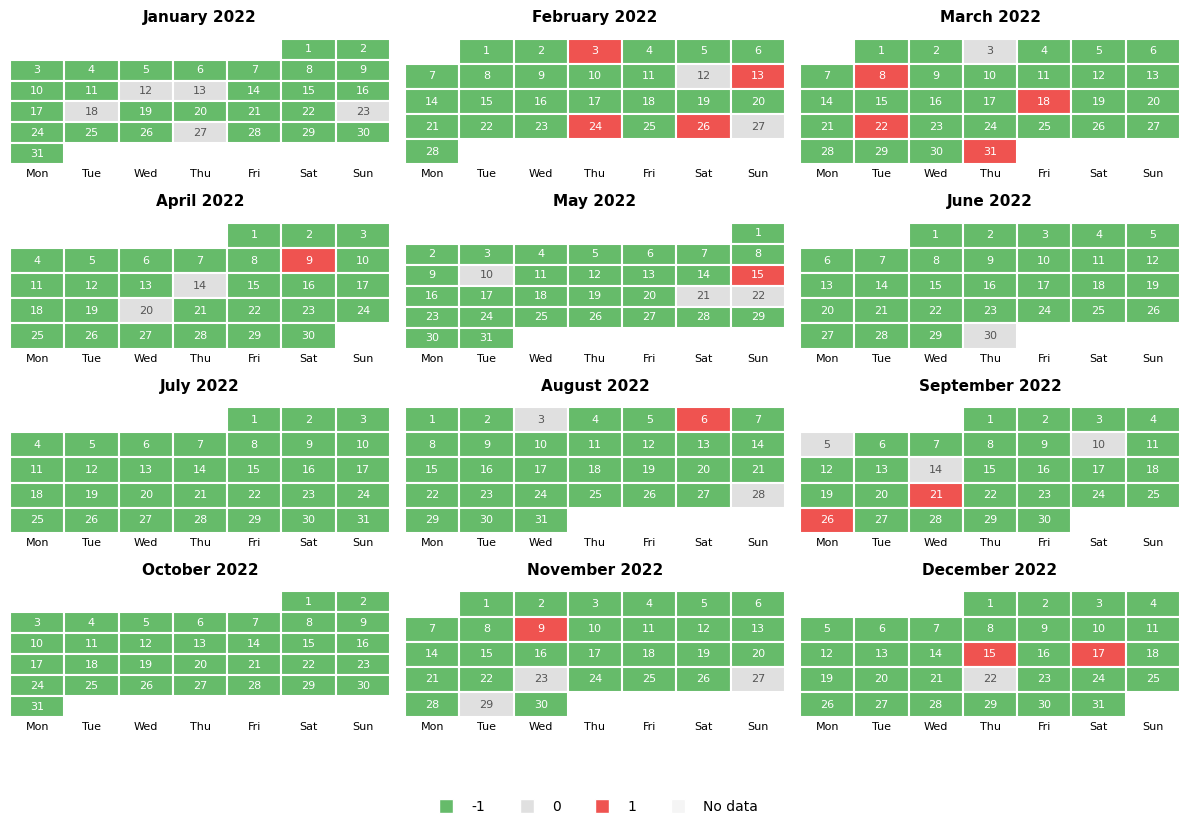

In [24]:
annotate_activity_days("SITE_003", 2022)

ON PLANNED POUR ACTIVITY BUT NO CONSUMPTION (1010 Instances)
- There was enough cement in the inventory to use (262 Instances)
- There was not enough cement for the planned pour (Including potential delivery) (531 Instances)
- There was not enough cement in inventory but delivery was made to cover (Potentially late delivery) (217 Instances).

In [25]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes > planned_pour_tonnes);
        """

con.execute(query).fetchone()

(262,)

In [26]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (closing_inventory_tonnes < planned_pour_tonnes);
        """

con.execute(query).fetchone()

(531,)

In [27]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes < planned_pour_tonnes)
                AND
                (closing_inventory_tonnes >= planned_pour_tonnes);
        """

con.execute(query).fetchone()

(217,)

In [28]:
data = con.execute(" SELECT site_id, rain_mm FROM Operations; ").df()

In [29]:
for site in data.site_id.unique():
    stat, p_value = shapiro(data.loc[data.site_id == site, "rain_mm"].values)
    if p_value > 0.05:
        print(f"Distribution of Rain at {site} is normal")

In [30]:
for site in data.site_id.unique():
    difference, p_value = ks_2samp(
        data.rain_mm.values,
        data.loc[data.site_id == site, "rain_mm"].values
    )
    if p_value < 0.05:
        print(f"Distribution of Rain at {site} is significantly different from general population: difference ({difference.round(3)}), p_value ({p_value.round(3)})")

Distribution of Rain at SITE_014 is significantly different from general population: difference (0.044), p_value (0.03)
Distribution of Rain at SITE_024 is significantly different from general population: difference (0.053), p_value (0.005)
Distribution of Rain at SITE_029 is significantly different from general population: difference (0.054), p_value (0.004)


In [31]:
def visualize_difference(site_id: str, data: pd.DataFrame = data) -> None:

    sample_distribution = data.loc[data.site_id == site_id, "rain_mm"].values
    population_distribution = data.rain_mm.values

    concat = np.concatenate([sample_distribution, population_distribution])
    uniques = np.unique(concat)
    uniques.sort()

    sample_cdf = np.array([sample_distribution[sample_distribution <= v].size / sample_distribution.size for v in uniques])
    population_cdf = np.array([population_distribution[population_distribution <= v].size / population_distribution.size for v in uniques])

    difference, p_value = ks_2samp(sample_distribution, population_distribution)

    fig, ax = plt.subplots(1, 3, figsize = (12, 10))

    sns.histplot(population_distribution, kde = True, ax = ax[0])
    sns.lineplot(x = uniques, y = population_cdf, color = "blue", ax = ax[1])
    sns.lineplot(x = uniques, y = sample_cdf, color = "red", ax = ax[1])
    sns.histplot(sample_distribution, kde = True, ax = ax[2])

    ax[0].set_title("Rain Distribution across Sites")
    ax[1].set_title(f"Rain Distribution Difference: {site_id} vs Other Sites")
    ax[2].set_title(f"Rain Distribution at {site_id}")

    plt.suptitle(f"Difference: {difference.round(3)}, P-Value: {p_value.round(3)}")

    plt.tight_layout()
    plt.show()

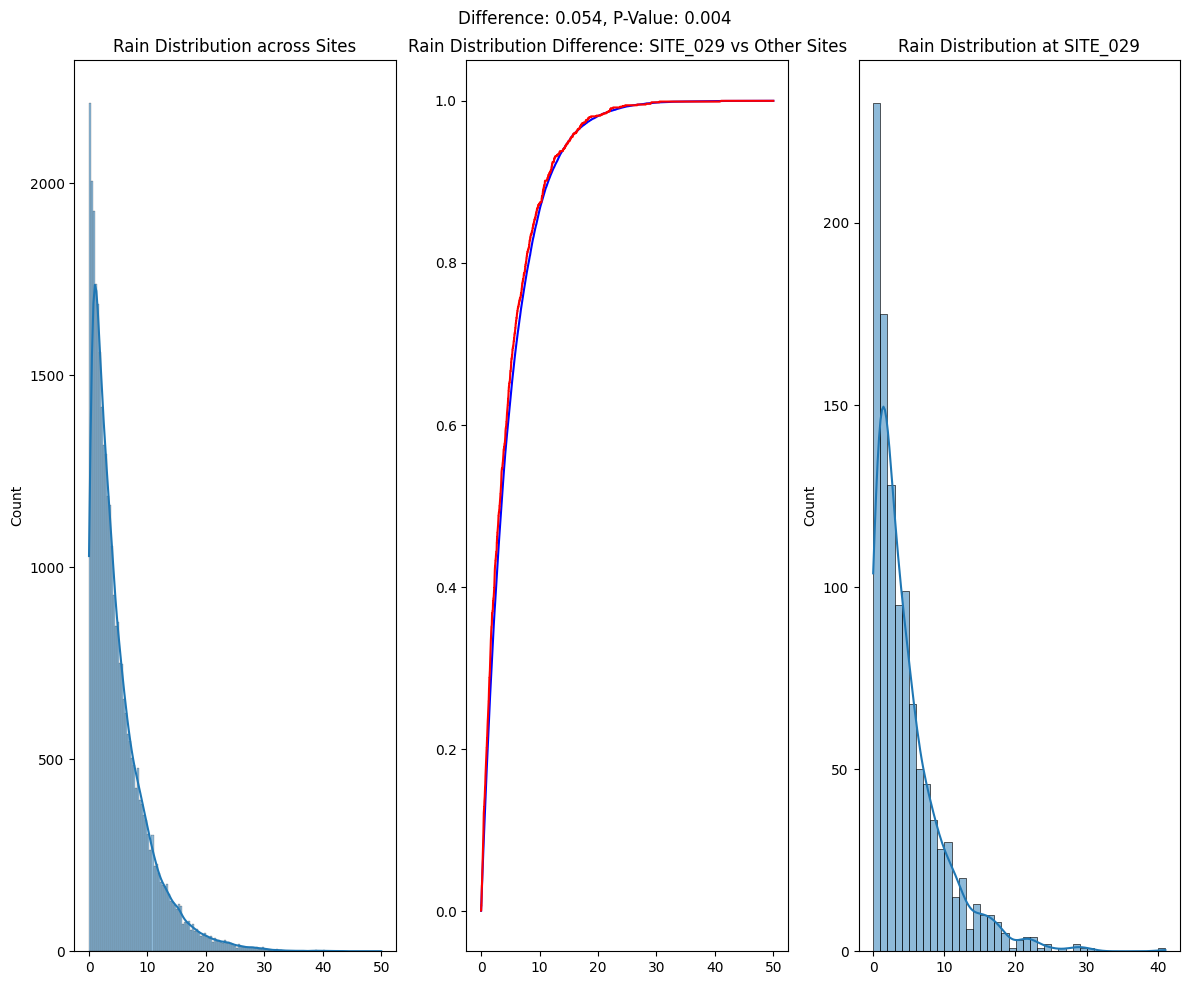

In [32]:
visualize_difference("SITE_029")

> NOT REALLY MUCH DIFFERENCE 

A CASE CAN BE MADE THAT HEAVY STORM MIGHT HAVE PREVENTED ACTIVITY WHEN IN FACT THERE WAS CEMENT AVAILABLE IN THE INVENTORY TO WORK WITH

In [33]:
query = """ SELECT
                rain_mm
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes > planned_pour_tonnes);
        """

idle_rain_data = con.execute(query).df().values.ravel()
active_rain_data = con.execute(" SELECT rain_mm FROM Operations WHERE consumed_tonnes > 0 ").df().values.ravel()

concat = np.concatenate([idle_rain_data, active_rain_data])
uniques = np.unique(concat)
uniques.sort()

idle_cdf = np.array([idle_rain_data[idle_rain_data <= v].size / idle_rain_data.size for v in uniques])
active_cdf = np.array([active_rain_data[active_rain_data <= v].size / active_rain_data.size for v in uniques])


difference, p_value = ks_2samp(idle_rain_data, active_rain_data)

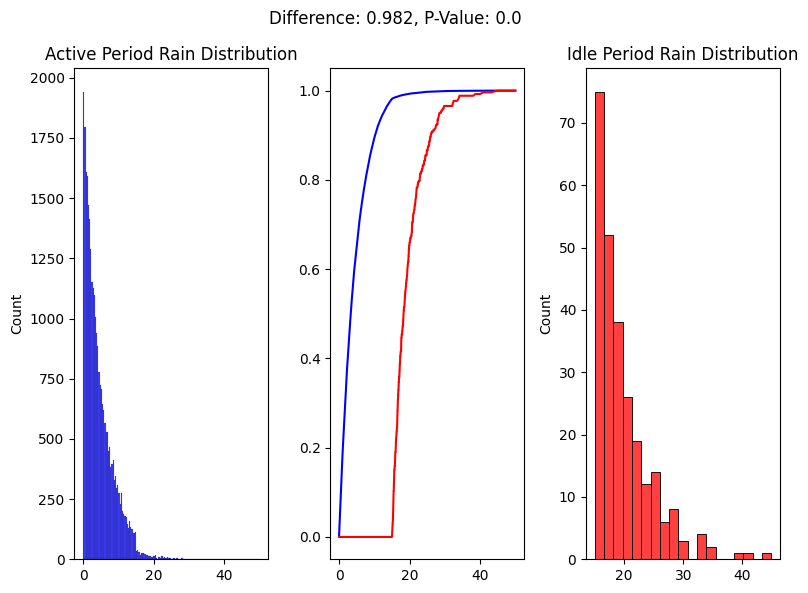

In [34]:
fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(active_rain_data, color = "blue", ax = ax[0])
sns.lineplot(x = uniques, y = active_cdf, color = "blue", ax = ax[1])
sns.lineplot(x = uniques, y = idle_cdf, color = "red", ax = ax[1])
sns.histplot(idle_rain_data, color = "red", ax = ax[2])


ax[0].set_title("Active Period Rain Distribution")
ax[2].set_title("Idle Period Rain Distribution")
plt.suptitle(f"Difference: {difference.round(3)}, P-Value: {p_value.round(3)}")

plt.tight_layout()
plt.show()

In [35]:
data = con.execute(" SELECT site_id, avg_temp_c FROM Operations; ").df()

In [36]:
for site in data.site_id.unique():
    stat, p_value = shapiro(data.loc[data.site_id == site, "avg_temp_c"].values)
    if p_value > 0.05:
        print(f"Temperature Distribution at {site} is normal")

In [37]:
for site in data.site_id.unique():
    difference, p_value = ks_2samp(
        data.avg_temp_c.values,
        data.loc[data.site_id == site, "avg_temp_c"].values
    )
    if p_value < 0.05:
        print(f"Distribution of Temperature at {site} is significantly different from general population: difference ({difference.round(3)}), p_value ({p_value.round(3)})")

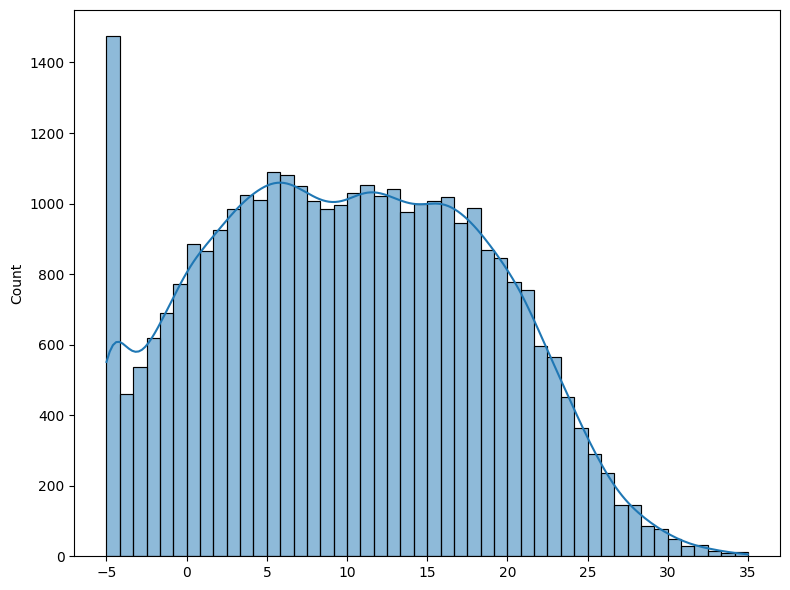

In [38]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.histplot(data.avg_temp_c.values, kde = True, ax = ax)

plt.tight_layout()
plt.show()

HEAVY STORM INFLUENCE THE DIFFERENCE BETWEEN PLANNED TONNES AND CONSUMED TONNES

In [39]:
query = """
    SELECT
        rain_mm,
        avg_temp_c,
        planned_pour_tonnes,
        consumed_tonnes,
        (planned_pour_tonnes - consumed_tonnes) delta
    FROM
        Operations;
"""

rain_effect_df = con.execute(query).df()

In [40]:
rain_effect_df["temp_category"] = pd.cut(
    rain_effect_df.avg_temp_c,
    bins = [-np.inf, 0, 10, 20, 30, np.inf],
    labels = ["sub_zero", "chilling", "cool", "ambient", "hot"]
)

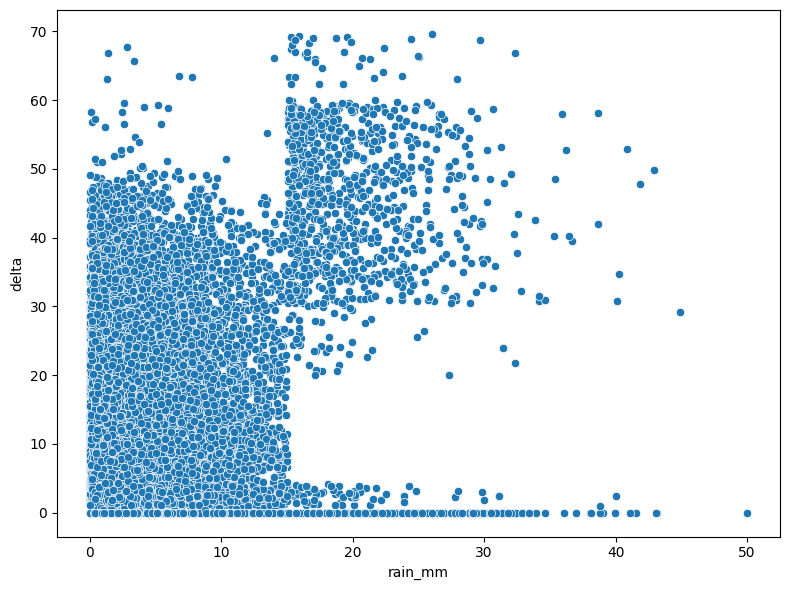

In [41]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = rain_effect_df, x = "rain_mm", y = "delta", ax = ax)

plt.tight_layout()
plt.show()

IT ISN'T THAT STORM EXPLAIN VARIANCE IN DIFFERENCE BETWEEN PLANNED AND CONSUMED CEMENT, IT IS JUST THAT; AT ABOVE 15MM, ACTIVITIES ARE MOST LIKELY HALTED.

In [42]:
rain_effect_df.loc[
    (rain_effect_df.delta > 25) &
    (rain_effect_df.rain_mm > 15)
]

,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta,temp_category
57,17.31,14.93,52.85,0.0,52.85,cool
60,21.34,15.27,44.45,0.0,44.45,cool
78,17.21,16.92,52.65,0.0,52.65,cool
128,28.84,30.93,41.92,0.0,41.92,hot
154,16.36,18.03,35.55,0.0,35.55,cool
...,...,...,...,...,...,...
32746,25.99,4.93,55.74,0.0,55.74,chilling
32814,17.74,14.75,30.51,0.0,30.51,cool
32832,23.89,7.42,46.99,0.0,46.99,chilling
32837,15.69,7.45,42.82,0.0,42.82,chilling


In [43]:
rain_effect_df.loc[
    (rain_effect_df.delta > 25) &
    (rain_effect_df.rain_mm > 15),
    "consumed_tonnes"
].value_counts()

consumed_tonnes
0.0    939
Name: count, dtype: int64

TEMPERATURE DOES NOT EXPLAIN THE VARIANCE IN THE DIFFERENCE BETWEEN PLANNED AND CONNSUMED TONNES

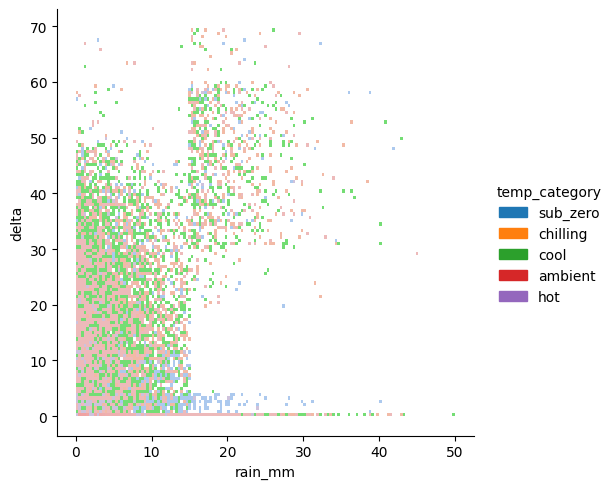

In [44]:
sns.displot(data = rain_effect_df, x = "rain_mm", y = "delta", hue = "temp_category", ax = ax)

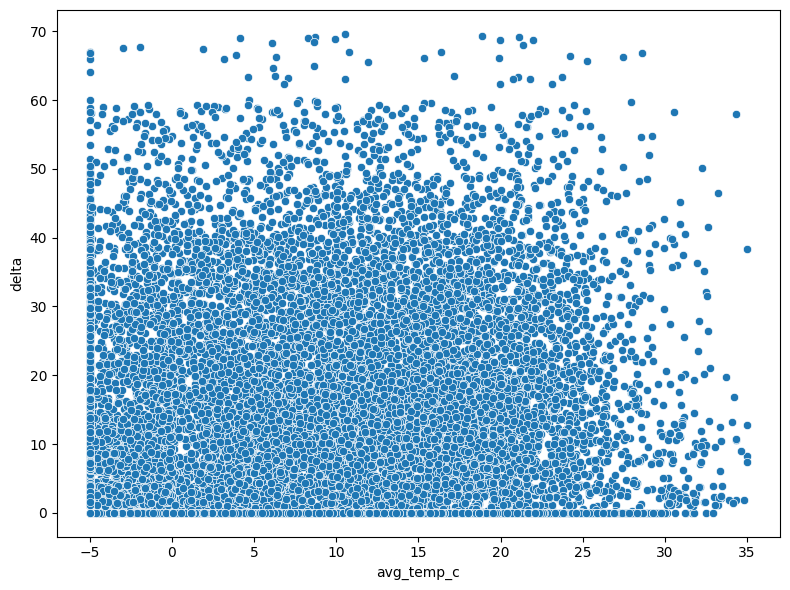

In [45]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = rain_effect_df, x = "avg_temp_c", y = "delta", ax = ax)

plt.tight_layout()
plt.show()

In [46]:
query = """

    SELECT
        date::DATE as date,
        site_id,
        cement_type,
        rain_mm,
        avg_temp_c,
        planned_pour_tonnes,
        consumed_tonnes
    FROM
        Operations
    ORDER BY
        date::DATE ASC
"""

data = con.execute(query).df()

In [47]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00


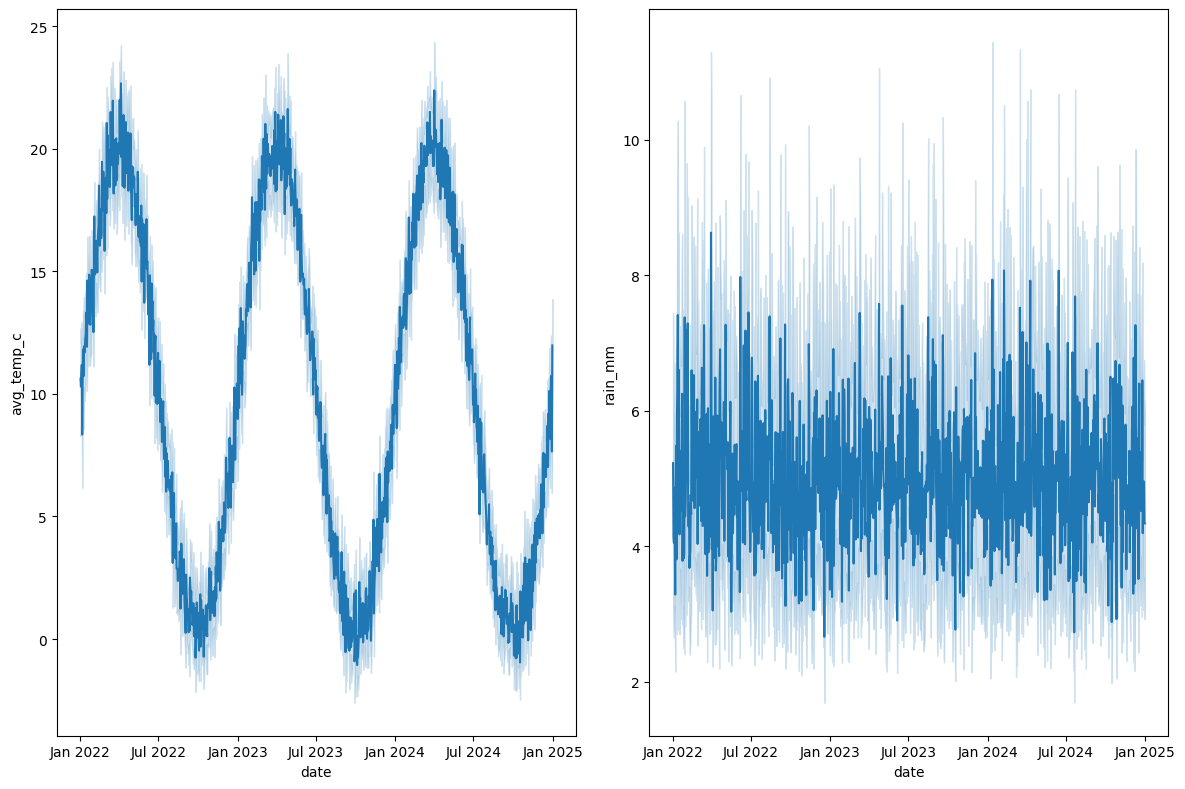

In [48]:
fig, ax = plt.subplots(1, 2, figsize = (12, 8))

sns.lineplot(data = data, x = "date", y = "avg_temp_c", ax = ax[0])
sns.lineplot(data = data, x = "date", y = "rain_mm", ax = ax[1])

ax[0].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=5))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[1].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=5))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [49]:
def correlation(site_a: str, site_b: str,
                variable: Literal["rain_mm", "avg_temp_c"] = "rain_mm",
                data: pd.DataFrame = data) -> Tuple[float, float]:

    series_a = data.loc[data.site_id == site_a, variable]
    series_b = data.loc[data.site_id == site_b, variable]

    coef, p_value = pearsonr(series_a, series_b)
    return coef.round(3), p_value.round(3)

RAIN PATTERN IS QUITE UNIQUE FOR EACH SITE BUT TEMPERATURE PATTERN IS HIGHLY CORRELATED ACROSS SITES

In [55]:
sites = data.site_id.unique().tolist()
sites.sort()

In [79]:
site_rain_pattern_correlation = []
site_rain_pattern_p_value = []
for site_a in sites:
    temp_correlation = []
    temp_pvlaue = []
    for site_b in sites:
        coef, p_value = correlation(site_a, site_b)

        temp_correlation.append(coef)
        temp_pvlaue.append(p_value)
    site_rain_pattern_correlation.append(temp_correlation)
    site_rain_pattern_p_value.append(temp_pvlaue)

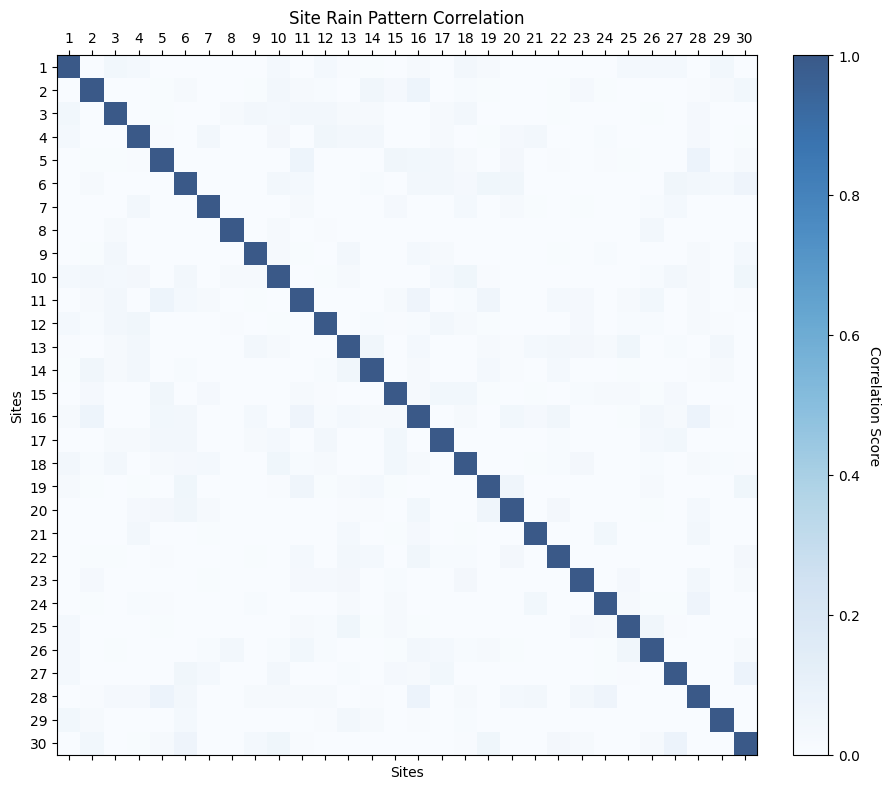

In [80]:
matrix = np.array(site_rain_pattern_correlation)
fig, ax = plt.subplots(figsize = (10, 8))

norm = mcolors.Normalize(vmin = 0, vmax = 1)

im = ax.matshow(matrix, cmap = plt.cm.Blues, norm = norm, alpha = 0.8)

# for i in range(matrix.shape[0]):
#     for j in range(matrix.shape[1]):
#         ax.text(x = j, y = i, s = matrix[i, j], va = "center", ha = "center", size = "small")

ax.set_xticks(range(matrix.shape[1]))
ax.set_yticks(range(matrix.shape[0]))

ax.set_xticklabels(range(1, 31))
ax.set_yticklabels(range(1, 31))

ax.set_xlabel("Sites", fontsize = 10)
ax.set_ylabel("Sites", fontsize = 10)

ax.set_title("Site Rain Pattern Correlation")

cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Score", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [76]:
site_temp_pattern_correlation = []
site_temp_pattern_p_value = []
for site_a in sites:
    temp_correlation = []
    temp_pvlaue = []
    for site_b in sites:
        coef, p_value = correlation(site_a, site_b, variable = "avg_temp_c")

        temp_correlation.append(coef)
        temp_pvlaue.append(p_value)
    site_temp_pattern_correlation.append(temp_correlation)
    site_temp_pattern_p_value.append(temp_pvlaue)

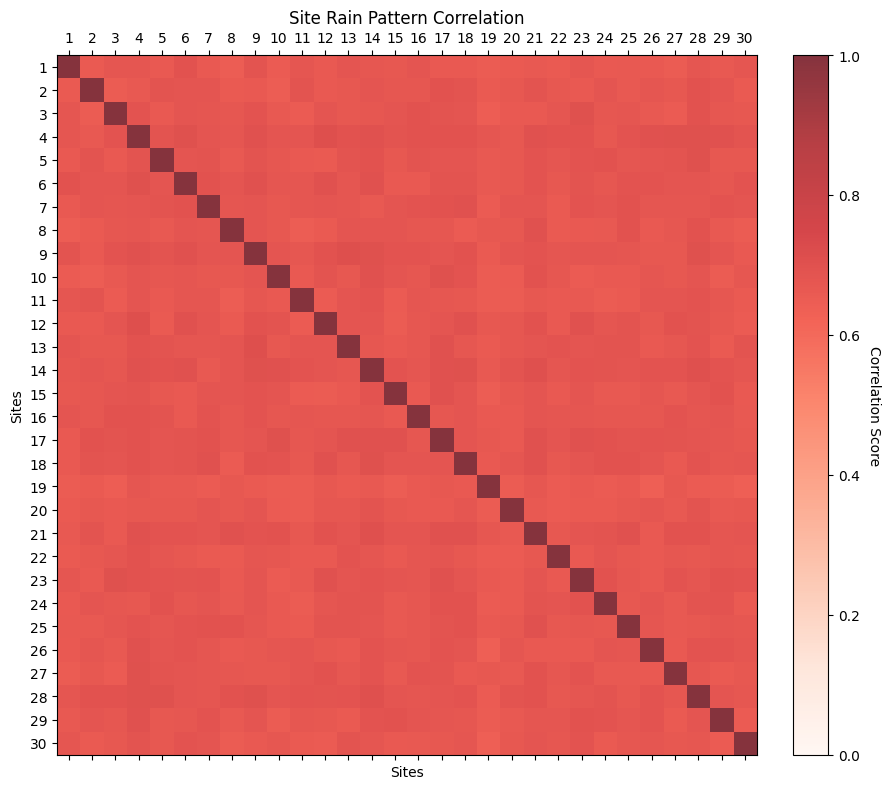

In [78]:
matrix = np.array(site_temp_pattern_correlation)
fig, ax = plt.subplots(figsize = (10, 8))

norm = mcolors.Normalize(vmin = 0, vmax = 1)

im = ax.matshow(matrix, cmap = plt.cm.Reds, norm = norm, alpha = 0.8)

# for i in range(matrix.shape[0]):
#     for j in range(matrix.shape[1]):
#         ax.text(x = j, y = i, s = matrix[i, j], va = "center", ha = "center", size = "small")

ax.set_xticks(range(matrix.shape[1]))
ax.set_yticks(range(matrix.shape[0]))

ax.set_xticklabels(range(1, 31))
ax.set_yticklabels(range(1, 31))

ax.set_xlabel("Sites", fontsize = 10)
ax.set_ylabel("Sites", fontsize = 10)

ax.set_title("Site Rain Pattern Correlation")

cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Score", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [100]:
site_cement_choice_by_type = data.groupby(by = ["site_id", "cement_type"], as_index = False)["consumed_tonnes"].sum()
site_cement_choice_by_type.consumed_tonnes = site_cement_choice_by_type.consumed_tonnes.round()
site_cement_choice_by_type.head()

,site_id,cement_type,consumed_tonnes
0,SITE_001,CEM_I,11265.0
1,SITE_001,CEM_II,11512.0
2,SITE_001,CEM_III,10279.0
3,SITE_002,CEM_I,4288.0
4,SITE_002,CEM_II,4025.0


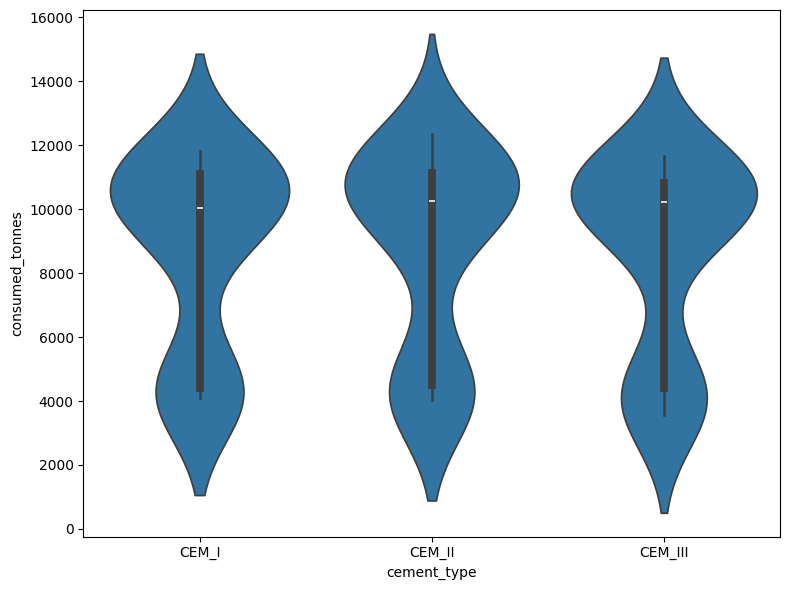

In [102]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.violinplot(data = site_cement_choice_by_type, x = "cement_type", y = "consumed_tonnes", ax = ax)

plt.tight_layout()
plt.show()

In [103]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00


In [113]:
data["delta"] = data["planned_pour_tonnes"] - data["consumed_tonnes"]

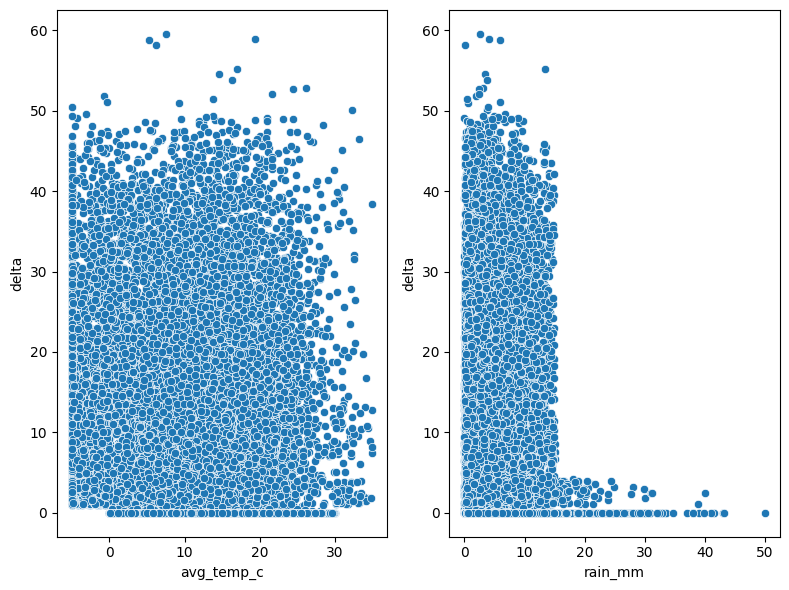

In [118]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.scatterplot(data = data.loc[data.consumed_tonnes > 0], x = "avg_temp_c", y = "delta", ax = ax[0])
sns.scatterplot(data = data.loc[data.consumed_tonnes > 0], x = "rain_mm", y = "delta", ax = ax[1])

plt.tight_layout()
plt.show()

In [160]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42


In [162]:
def kpss_test(series: pd.Series) -> Tuple[float, float, str]:

    stat, p_value, _, _, = kpss(
        series, regression = "c"
    )

    decision = "non-stationary" if p_value < 0.05 else "stationary"

    return stat.round(3), p_value.round(3), decision

def adf_test(series: pd.Series) -> Tuple[float, float, str]:
    result = adfuller(series)
    stat, p_value = result[0].round(3), result[1].round(3)
    decision = "stationary" if p_value < 0.05 else "non-stationary"

    return stat, p_value, decision

In [263]:
def cement_usage_trend(site_id: str, cement_type: Literal["CEM_I", "CEM_II", "CEM_III"],
                       variable: Literal["consumed_tonnes", "planned_pour_tonnes"] = "consumed_tonnes",
                       cadence: Optional[str] = None) -> pd.DataFrame:

    query = f"""

                WITH date_range AS (
                    SELECT
                        *
                    FROM
                        generate_series(
                            DATE '{OPERATION_START_DATE}',
                            DATE '{OPERATION_END_DATE}',
                            INTERVAL '1 day'
                        ) AS date_range(date)
                ),
                site_data AS (
                    SELECT
                        CAST(date AS DATE) AS date,
                        {variable}
                    FROM
                        Operations
                    WHERE
                        site_id = '{site_id}'
                        AND
                        cement_type = '{cement_type}'
                    ORDER BY
                        date ASC
                ),
                full_data AS (
                    SELECT
                        dr.date,
                        COALESCE(sd.{variable}, 0) AS {variable}
                    FROM
                        date_range AS dr
                    LEFT JOIN
                        site_data AS sd
                    ON
                        dr.date = sd.date
                    ORDER BY
                        dr.date ASC
                )
                SELECT
                    time_bucket('{cadence}', date) AS week,
                    SUM({variable}) AS {variable}
                FROM
                    full_data
                GROUP BY 1
                ORDER BY 1;
            """

    return con.execute(query).df()


In [286]:
site_usage = cement_usage_trend("SITE_001", "CEM_I", "consumed_tonnes", cadence = "1 week")

In [294]:
kpss_candidates = []
adf_candidates = []

for site in sites:
    for cement in ["CEM_I", "CEM_II", "CEM_III"]:
        for variable in ["consumed_tonnes", "planned_pour_tonnes"]:
            for cadence in ["1 week", "2 weeks", "3 weeks", "4 weeks"]:
                usage_trend = cement_usage_trend(
                    site_id = site, cement_type = cement,
                    variable = variable, cadence = cadence
                )
                _, _, adf_decision = adf_test(usage_trend[variable])
                _, _, kpss_decision = kpss_test(usage_trend[variable])

                if kpss_decision == "non-stationary":
                    kpss_candidates.append(
                        {
                            "site_id": site,
                            "cement_type": cement,
                            "variable": variable,
                            "cadence": cadence
                        }
                    )
                if adf_decision == "non-stationary":
                    adf_candidates.append(
                        {
                            "site_id": site,
                            "cement_type": cement,
                            "variable": variable,
                            "cadence": cadence
                        }
                    )

In [295]:
len(kpss_candidates), len(adf_candidates)

(20, 29)

In [313]:
set([", ".join(e.values()) for e in kpss_candidates]).intersection([", ".join(e.values()) for e in adf_candidates])

{'SITE_006, CEM_II, consumed_tonnes, 4 weeks',
 'SITE_028, CEM_I, planned_pour_tonnes, 2 weeks'}

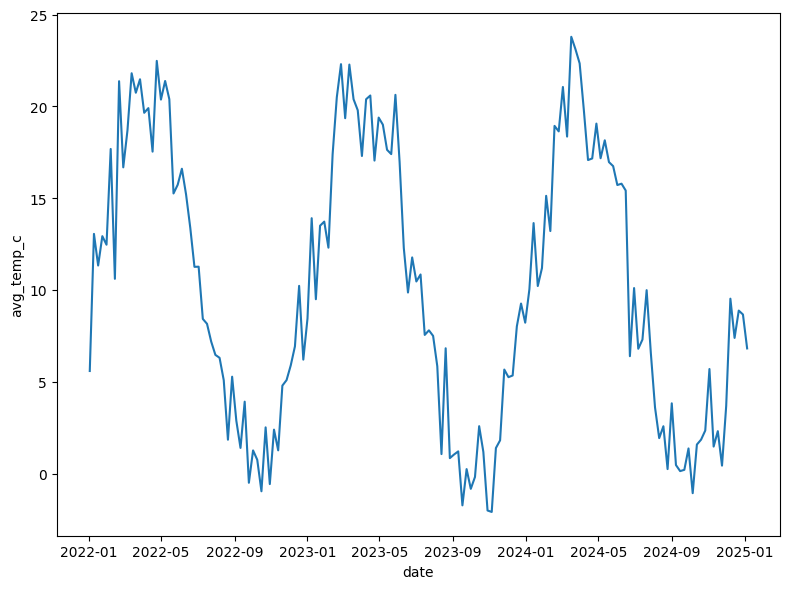

In [390]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = data.loc[data.site_id == "SITE_001"].set_index('date').resample("W")["avg_temp_c"].mean().to_frame().reset_index(), x = "date", y = "avg_temp_c", ax = ax)

plt.tight_layout()
plt.show()

In [536]:
def lag_correlation(series: np.ndarray, nlags: int, alpha: float = 0.05) -> List[Tuple[int, float]]:

    coef_values = []
    pvalues = []
    lags = []
    for i in range(1, nlags + 1):
        coef, pvalue = pearsonr(
            series.shift(i).dropna().reset_index(drop = True),
            series.iloc[i:].reset_index(drop = True)
        )

        if pvalue < alpha:
            coef_values.append(coef.round(3))
            pvalues.append(pvalue.round(3))
            lags.append(i)

    result = pd.DataFrame(
        data = {
            "lags": lags,
            "coef": coef_values,
            "pvalue": pvalues,
        }
    )

    return result

In [577]:
usage_trend = cement_usage_trend(**kpss_candidates[14])
usage_trend.head()

,week,planned_pour_tonnes
0,2021-12-27,0.00
1,2022-01-03,111.71
2,2022-01-10,102.89
3,2022-01-17,95.72
4,2022-01-24,118.32


In [578]:
lag_correlation(
    usage_trend.planned_pour_tonnes,
    nlags = 60,
    alpha = 0.05
)

,lags,coef,pvalue


In [579]:
stl = STL(usage_trend.planned_pour_tonnes.values, period = 7, robust = True).fit()

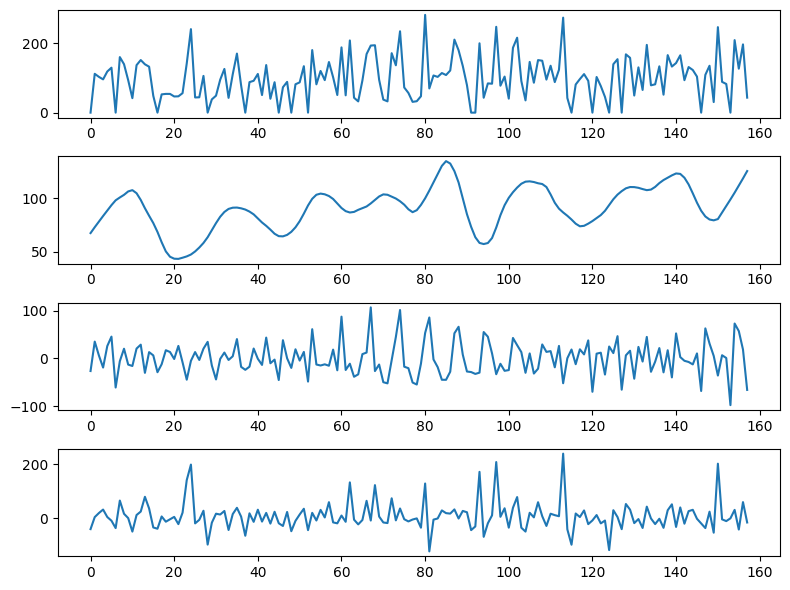

In [580]:
fig, ax = plt.subplots(4, 1, figsize = (8, 6))

sns.lineplot(usage_trend.planned_pour_tonnes.values, ax = ax[0])
sns.lineplot(stl.trend, ax = ax[1])
sns.lineplot(stl.seasonal, ax = ax[2])
sns.lineplot(stl.resid, ax = ax[3])

plt.tight_layout()
plt.show()

In [581]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42


In [583]:
con.execute("SELECT * FROM Sites;").df()

,site_id,region,silo_capacity,behavior
0,SITE_001,North,448,aggressive
1,SITE_002,South,288,conservative
2,SITE_003,East,314,aggressive
3,SITE_004,South,472,conservative
4,SITE_005,South,230,aggressive
5,SITE_006,East,443,chaotic
6,SITE_007,East,485,aggressive
7,SITE_008,West,260,aggressive
8,SITE_009,East,352,conservative
9,SITE_010,West,158,aggressive


In [629]:
query = """

    WITH site_cement_sort AS (
        SELECT
            CAST(date AS DATE) AS date,
            site_id,
            cement_type,
            opening_inventory_tonnes,
            closing_inventory_tonnes,
            ROW_NUMBER() OVER (PARTITION BY site_id, cement_type ORDER BY date ASC) AS rank
        FROM
            Operations
    )

    SELECT
        *
    FROM
        site_cement_sort
    ORDER BY
        site_id ASC,
        cement_type ASC,
        date ASC;
"""

con.execute(query).df().head()

,date,site_id,cement_type,opening_inventory_tonnes,closing_inventory_tonnes,rank
0,2022-01-02,SITE_001,CEM_I,63.85,38.56,1
1,2022-01-04,SITE_001,CEM_I,47.06,32.64,2
2,2022-01-07,SITE_001,CEM_I,0.00,14.12,3
3,2022-01-08,SITE_001,CEM_I,14.12,0.00,4
4,2022-01-09,SITE_001,CEM_I,0.00,34.38,5


In [612]:
site_one = con.execute(" SELECT * FROM Operations WHERE site_id == 'SITE_001' ORDER BY date ASC; ").df()
site_one.date = pd.to_datetime(site_one.date)
site_one.sort_values(by = ["cement_type", "date"], ascending = [True, True], inplace = True)
site_one.reset_index(drop = True, inplace = True)
site_one.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
1,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
2,2022-01-07,SITE_001,CEM_I,33.60,33.60,0.00,47.72,14.12,0.90,4.48,448
3,2022-01-08,SITE_001,CEM_I,42.12,34.28,14.12,20.16,0.00,1.95,25.92,448
4,2022-01-09,SITE_001,CEM_I,0.00,0.00,0.00,34.38,34.38,1.42,16.81,448


In [613]:
mask = site_one.opening_inventory_tonnes == site_one.groupby("cement_type")["closing_inventory_tonnes"].shift(1)

In [621]:
sum(mask)

579

In [622]:
site_one.shape

(1096, 11)

In [620]:
site_one.loc[12:19, :]

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
12,2022-02-03,SITE_001,CEM_I,31.12,31.12,8.91,24.41,2.2,9.85,15.79,448
13,2022-02-04,SITE_001,CEM_I,43.72,19.98,2.20,17.78,0.0,0.68,23.33,448
14,2022-02-09,SITE_001,CEM_I,52.14,49.03,14.56,34.47,0.0,5.08,12.95,448
15,2022-02-10,SITE_001,CEM_I,33.60,13.67,0.00,13.67,0.0,2.72,12.70,448
16,2022-02-12,SITE_001,CEM_I,43.94,11.92,0.00,11.92,0.0,0.51,0.41,448
17,2022-02-17,SITE_001,CEM_I,32.83,14.95,2.10,12.85,0.0,2.37,19.47,448
18,2022-02-19,SITE_001,CEM_I,59.03,26.94,0.00,26.94,0.0,6.64,21.72,448
19,2022-02-21,SITE_001,CEM_I,50.40,26.71,7.18,19.53,0.0,4.13,20.33,448


In [618]:
site_one.loc[mask].head(30)

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
3,2022-01-08,SITE_001,CEM_I,42.12,34.28,14.12,20.16,0.00,1.95,25.92,448
4,2022-01-09,SITE_001,CEM_I,0.00,0.00,0.00,34.38,34.38,1.42,16.81,448
9,2022-01-27,SITE_001,CEM_I,39.51,34.90,2.63,32.27,0.00,0.39,9.58,448
11,2022-02-02,SITE_001,CEM_I,34.65,34.65,0.00,43.56,8.91,0.49,12.81,448
12,2022-02-03,SITE_001,CEM_I,31.12,31.12,8.91,24.41,2.20,9.85,15.79,448
13,2022-02-04,SITE_001,CEM_I,43.72,19.98,2.20,17.78,0.00,0.68,23.33,448
15,2022-02-10,SITE_001,CEM_I,33.60,13.67,0.00,13.67,0.00,2.72,12.70,448
16,2022-02-12,SITE_001,CEM_I,43.94,11.92,0.00,11.92,0.00,0.51,0.41,448
18,2022-02-19,SITE_001,CEM_I,59.03,26.94,0.00,26.94,0.00,6.64,21.72,448
20,2022-02-22,SITE_001,CEM_I,39.60,25.57,0.00,25.57,0.00,2.37,16.17,448


In [ ]:
site_one.opening_inventory_tonnes - site_one.groupby("cement_type")["closing_inventory_tonnes"].shift(1)

silo_capacity
448    1096
Name: count, dtype: int64

In [591]:
site_one.opening_inventory_tonnes.iloc[1:].reset_index(drop = True)

0       63.85
1       38.56
2       47.06
3       32.64
4        0.00
        ...  
1090     0.00
1091     0.00
1092     0.00
1093     3.10
1094    35.47
Name: opening_inventory_tonnes, Length: 1095, dtype: float64

In [590]:
site_one.closing_inventory_tonnes.shift(1).dropna().reset_index(drop = True)

0       63.85
1       38.56
2       47.06
3       32.64
4        0.00
        ...  
1090     0.00
1091     0.00
1092     0.00
1093     3.10
1094    35.47
Name: closing_inventory_tonnes, Length: 1095, dtype: float64

In [597]:
site_one.groupby("cement_type").transform(lambda x: x["opening_inventory_tonnes"] - x["closing_inventory_tonnes"].shift(1))

KeyError: 'opening_inventory_tonnes'